# 01 — Analyse Exploratoire des Données (EDA)

**Projet MLOps M2 — Détection de Fraude Bancaire**

Dataset : Credit Card Fraud Detection (UCI ML Repository)  
284 807 transactions | 492 fraudes | déséquilibre : 0.172%

## Objectifs de ce notebook
1. Comprendre la structure et la qualité des données
2. Analyser la distribution des features et de la cible
3. Identifier les outliers et patterns temporels
4. Justifier le choix des métriques d'évaluation
5. Orienter les choix de preprocessing et de modélisation

In [2]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from pathlib import Path

# Project modules
from src.data.loader import load_raw_data, get_feature_names, TARGET_COL, AMOUNT_COL, TIME_COL, PCA_FEATURES
from src.data.quality_gate import DataQualityGate

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
SEED = 42
np.random.seed(SEED)

DATA_PATH = Path('../data/raw/creditcard.csv')
print('Setup complet ✅')

Setup complet ✅


---
## 1. Chargement et aperçu général

In [3]:
df = load_raw_data(DATA_PATH)
print(f'Shape : {df.shape}')
print(f'Mémoire : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head()

Shape : (284807, 31)
Mémoire : 70.6 MB


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

In [5]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.860,47488.146,0.000,54201.500,84692.000,139320.500,172792.000
V1,284807.0,0.000,1.959,-56.408,-0.920,0.018,1.316,2.455
V2,284807.0,0.000,1.651,-72.716,-0.599,0.065,0.804,22.058
V3,284807.0,-0.000,1.516,-48.326,-0.890,0.180,1.027,9.383
V4,284807.0,0.000,1.416,-5.683,-0.849,-0.020,0.743,16.875
V5,284807.0,0.000,1.380,-113.743,-0.692,-0.054,0.612,34.802
V6,284807.0,0.000,1.332,-26.161,-0.768,-0.274,0.399,73.302
V7,284807.0,-0.000,1.237,-43.557,-0.554,0.040,0.570,120.589
V8,284807.0,0.000,1.194,-73.217,-0.209,0.022,0.327,20.007
V9,284807.0,-0.000,1.099,-13.434,-0.643,-0.051,0.597,15.595


---
## 2. Analyse de la variable cible — Déséquilibre des classes

Normal (0)  : 284,315 (99.827%)
Fraude  (1) : 492 (0.173%)

Ratio déséquilibre : 1 fraude pour 578 transactions normales


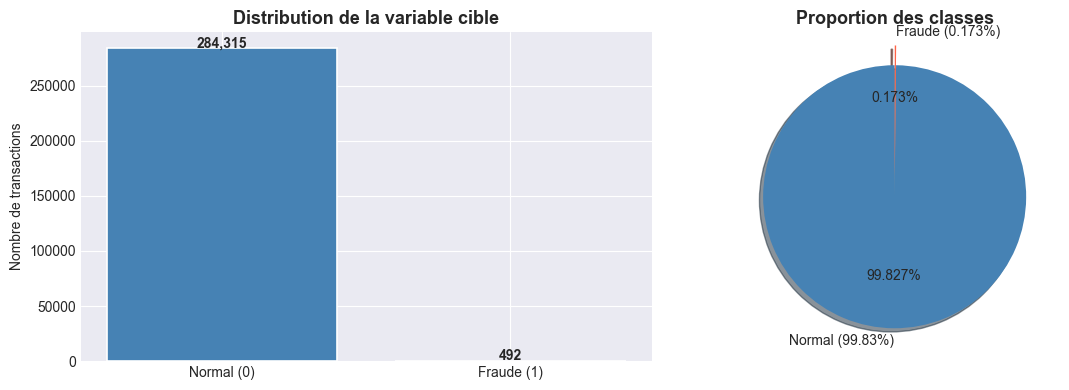


⚠️  Le déséquilibre extrême (0.172%) rend l'accuracy inutilisable comme métrique.
✅ Métrique principale recommandée : PR-AUC (AUPRC)


In [6]:
class_counts = df[TARGET_COL].value_counts()
fraud_rate = df[TARGET_COL].mean()

print(f'Normal (0)  : {class_counts[0]:,} ({(1-fraud_rate)*100:.3f}%)')
print(f'Fraude  (1) : {class_counts[1]:,} ({fraud_rate*100:.3f}%)')
print(f'\nRatio déséquilibre : 1 fraude pour {int(1/fraud_rate):,} transactions normales')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['Normal (0)', 'Fraude (1)'], class_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribution de la variable cible', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de transactions')
for bar, val in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}', ha='center', fontweight='bold')

# Pie chart (log scale pour visualiser le 0.172%)
axes[1].pie(
    class_counts.values,
    labels=[f'Normal ({(1-fraud_rate)*100:.2f}%)', f'Fraude ({fraud_rate*100:.3f}%)'],
    colors=['steelblue', 'tomato'],
    autopct='%1.3f%%',
    startangle=90,
    explode=[0, 0.15],
    shadow=True
)
axes[1].set_title('Proportion des classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n⚠️  Le déséquilibre extrême (0.172%) rend l\'accuracy inutilisable comme métrique.')
print('✅ Métrique principale recommandée : PR-AUC (AUPRC)')

---
## 3. Valeurs manquantes et qualité des données

In [7]:
missing = df.isnull().sum()
print('Valeurs manquantes par colonne :')
print(missing[missing > 0] if missing.any() else '✅ Aucune valeur manquante')

# Duplicates
dup_count = df.duplicated().sum()
print(f'\nDoublons exacts : {dup_count} ({dup_count/len(df)*100:.4f}%)')

Valeurs manquantes par colonne :
✅ Aucune valeur manquante

Doublons exacts : 1081 (0.3796%)


In [8]:
# Lancer le CI-3 Data Quality Gate
gate = DataQualityGate()
report = gate.run(df)
print('Gate passed:', report.passed)

[QUALITY GATE] WARNING: Dataset contains 1081 duplicate rows.


=== Data Quality Report ===
✅ All quality checks passed.

⚠️  1 warning(s):
  • Dataset contains 1081 duplicate rows.
Gate passed: True


---
## 4. Analyse de Amount et Time

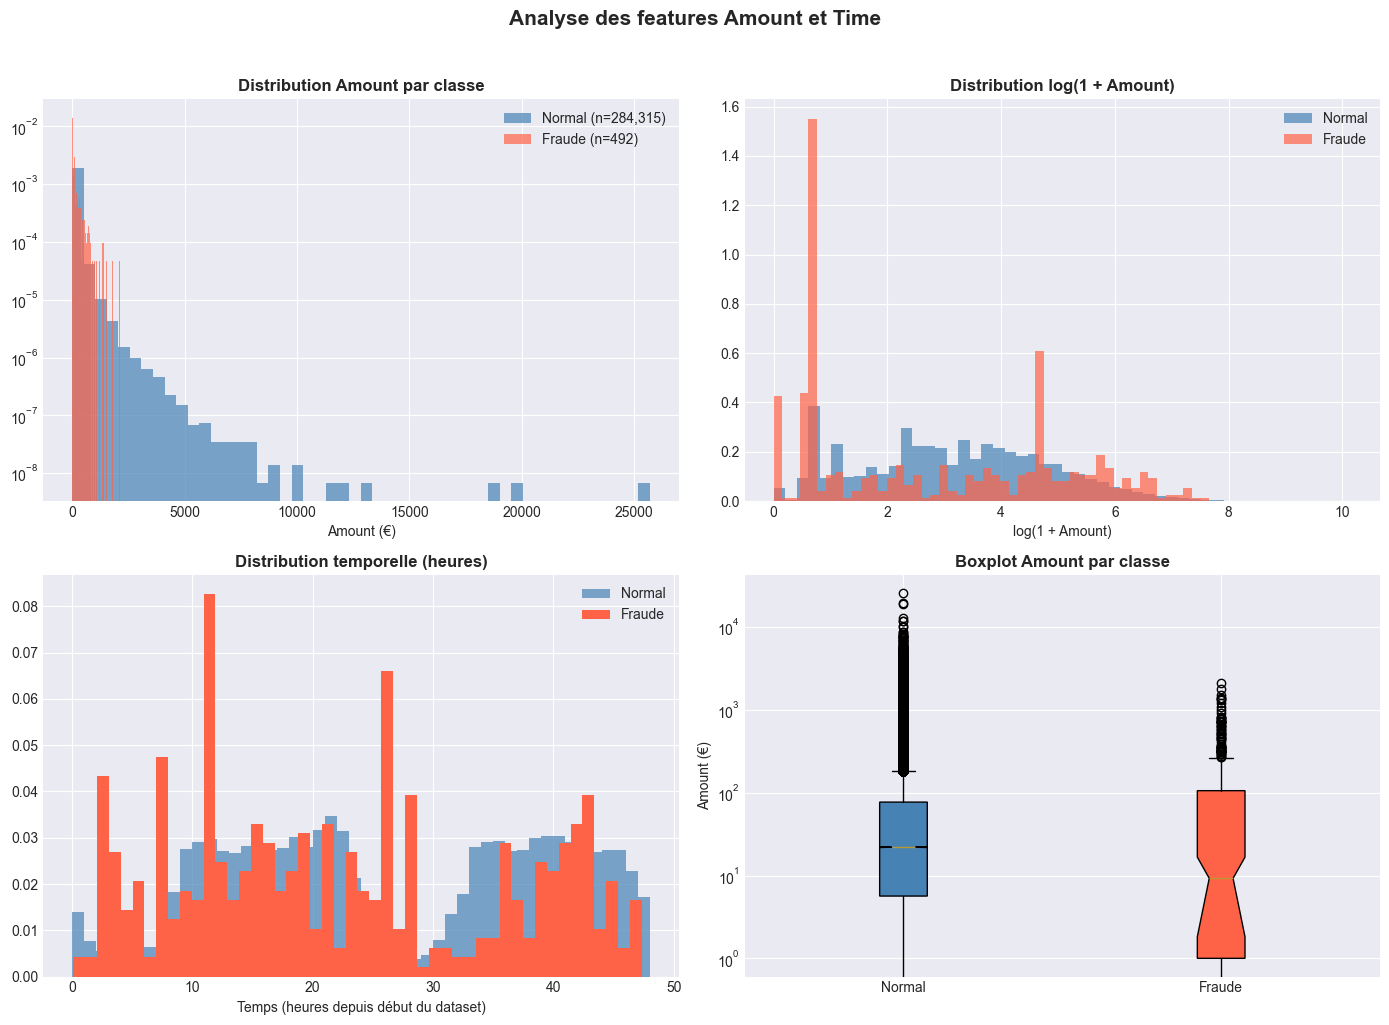

Amount — stats par classe:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution by class
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    subset = df[df[TARGET_COL] == label][AMOUNT_COL]
    axes[0, 0].hist(subset, bins=50, alpha=0.7, color=color,
                    label=f"{'Normal' if label==0 else 'Fraude'} (n={len(subset):,})",
                    density=True)
axes[0, 0].set_title('Distribution Amount par classe', fontweight='bold')
axes[0, 0].set_xlabel('Amount (€)')
axes[0, 0].legend()
axes[0, 0].set_yscale('log')

# Amount log distribution
log_amount = np.log1p(df[AMOUNT_COL])
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    mask = df[TARGET_COL] == label
    axes[0, 1].hist(log_amount[mask], bins=50, alpha=0.7, color=color,
                    label=f"{'Normal' if label==0 else 'Fraude'}",
                    density=True)
axes[0, 1].set_title('Distribution log(1 + Amount)', fontweight='bold')
axes[0, 1].set_xlabel('log(1 + Amount)')
axes[0, 1].legend()

# Time patterns — fraude vs normal
time_hours = df[TIME_COL] / 3600
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    mask = df[TARGET_COL] == label
    axes[1, 0].hist(time_hours[mask], bins=48, alpha=0.7 if label==0 else 1.0,
                    color=color, density=True,
                    label=f"{'Normal' if label==0 else 'Fraude'}")
axes[1, 0].set_title('Distribution temporelle (heures)', fontweight='bold')
axes[1, 0].set_xlabel('Temps (heures depuis début du dataset)')
axes[1, 0].legend()

# Boxplot Amount par classe
data_to_plot = [df[df[TARGET_COL]==0][AMOUNT_COL], df[df[TARGET_COL]==1][AMOUNT_COL]]
bp = axes[1, 1].boxplot(data_to_plot, labels=['Normal', 'Fraude'],
                         patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('tomato')
axes[1, 1].set_title('Boxplot Amount par classe', fontweight='bold')
axes[1, 1].set_ylabel('Amount (€)')
axes[1, 1].set_yscale('log')

plt.suptitle('Analyse des features Amount et Time', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/eda_amount_time.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats comparées
print('Amount — stats par classe:')
print(df.groupby(TARGET_COL)[AMOUNT_COL].describe().round(2))

---
## 5. Analyse des features PCA (V1–V28)

Top 10 features les plus discriminantes (séparabilité médiane normalisée) :
V14    7.0746
V17    6.1673
V12    5.6487
V16    4.1280
V10    4.1208
V11    3.5477
V3     3.4674
V4     2.9661
V7     2.4861
V18    1.9824
dtype: float64


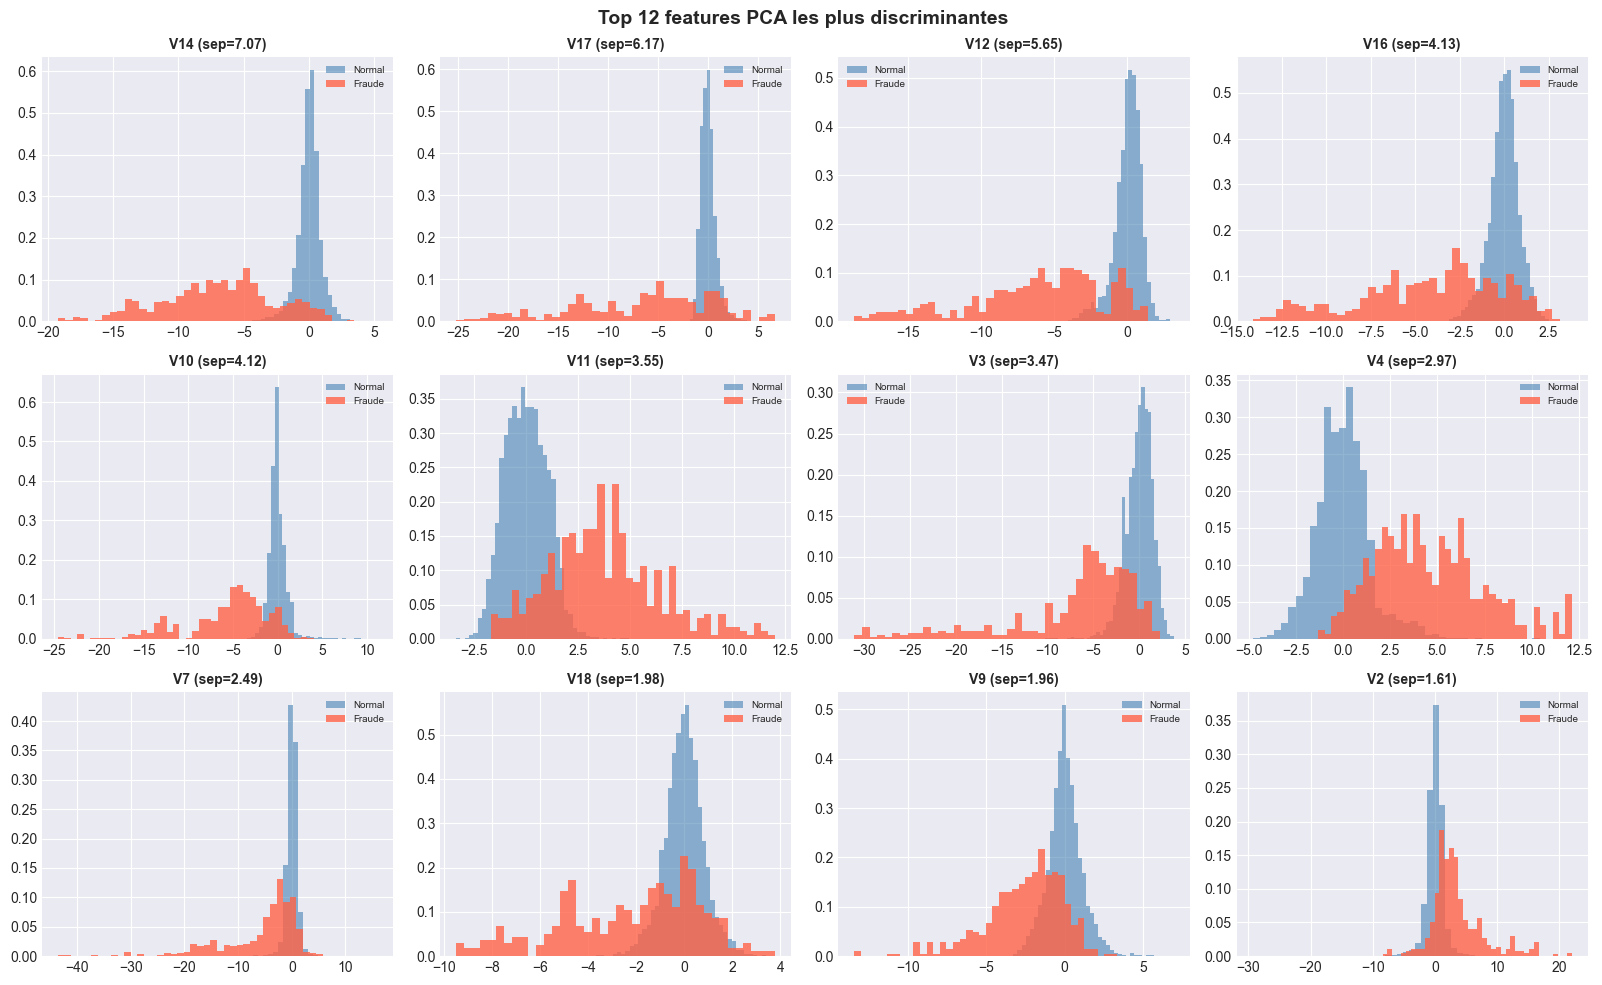

In [10]:
# Distribution des features PCA par classe — violin plots des plus discriminantes
# Calculer la séparabilité (différence des médianes normalisée)
fraud = df[df[TARGET_COL] == 1]
normal = df[df[TARGET_COL] == 0]

sep_scores = {}
for col in PCA_FEATURES:
    diff = abs(fraud[col].median() - normal[col].median())
    std_pooled = df[col].std()
    sep_scores[col] = diff / std_pooled if std_pooled > 0 else 0

sep_df = pd.Series(sep_scores).sort_values(ascending=False)
print('Top 10 features les plus discriminantes (séparabilité médiane normalisée) :')
print(sep_df.head(10).round(4))

# Plot — top 12 features
top_features = sep_df.head(12).index.tolist()
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

sample_fraud = fraud[top_features].sample(min(500, len(fraud)), random_state=SEED)
sample_normal = normal[top_features].sample(min(5000, len(normal)), random_state=SEED)

for i, col in enumerate(top_features):
    axes[i].hist(sample_normal[col], bins=40, alpha=0.6, color='steelblue',
                 density=True, label='Normal')
    axes[i].hist(sample_fraud[col], bins=40, alpha=0.8, color='tomato',
                 density=True, label='Fraude')
    axes[i].set_title(f'{col} (sep={sep_scores[col]:.2f})', fontweight='bold', fontsize=10)
    axes[i].legend(fontsize=7)

plt.suptitle('Top 12 features PCA les plus discriminantes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/eda_pca_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Matrice de corrélation

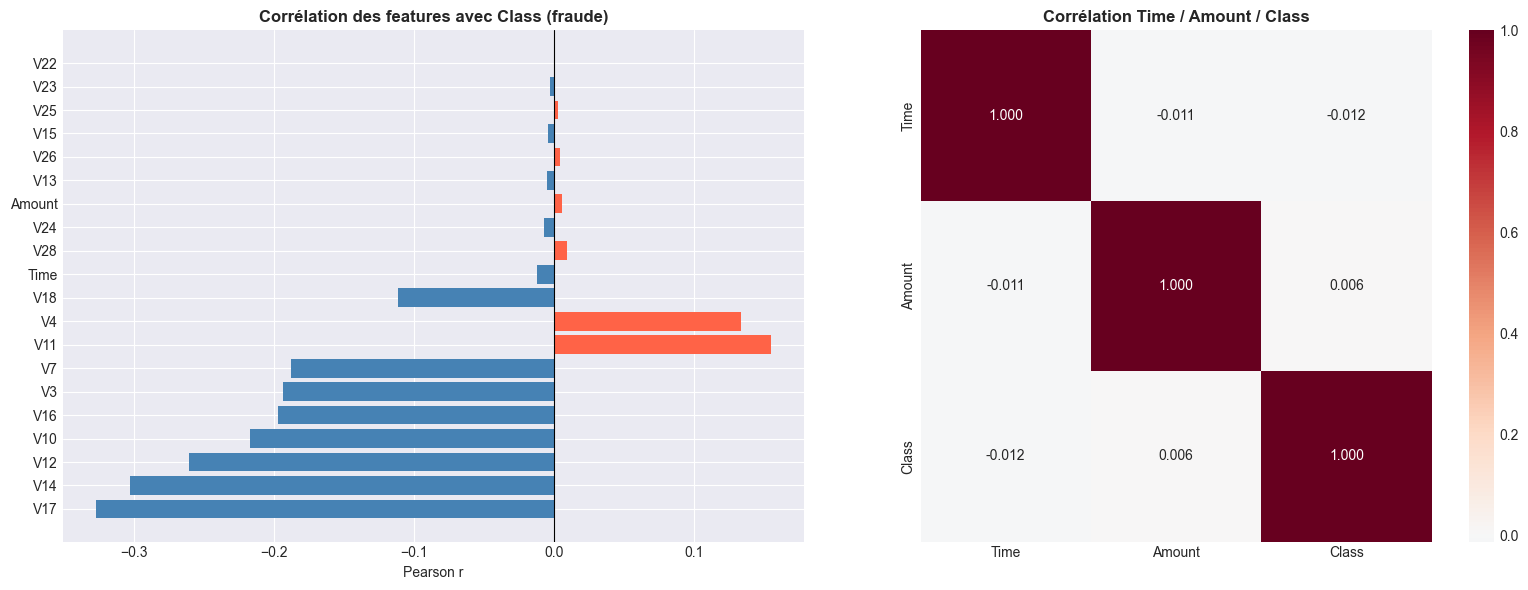

In [11]:
# Corrélation avec la variable cible
corr_with_target = df.corr()[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top corrélations avec Class
top_corrs = pd.concat([corr_with_target.head(10), corr_with_target.tail(10)])
colors = ['tomato' if v > 0 else 'steelblue' for v in top_corrs.values]
axes[0].barh(range(len(top_corrs)), top_corrs.values, color=colors)
axes[0].set_yticks(range(len(top_corrs)))
axes[0].set_yticklabels(top_corrs.index)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Corrélation des features avec Class (fraude)', fontweight='bold')
axes[0].set_xlabel('Pearson r')

# Heatmap sur features non-PCA + target
non_pca_cols = [TIME_COL, AMOUNT_COL, TARGET_COL]
corr_matrix = df[non_pca_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=axes[1], square=True)
axes[1].set_title('Corrélation Time / Amount / Class', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/eda_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Détection d'outliers sur Amount

Amount percentiles :
  95th : 365.00 €
  99.9th : 3000.00 €
  Max : 25691.16 €

Outliers (>99.9th percentile) : 284 transactions
  dont fraudes : 0


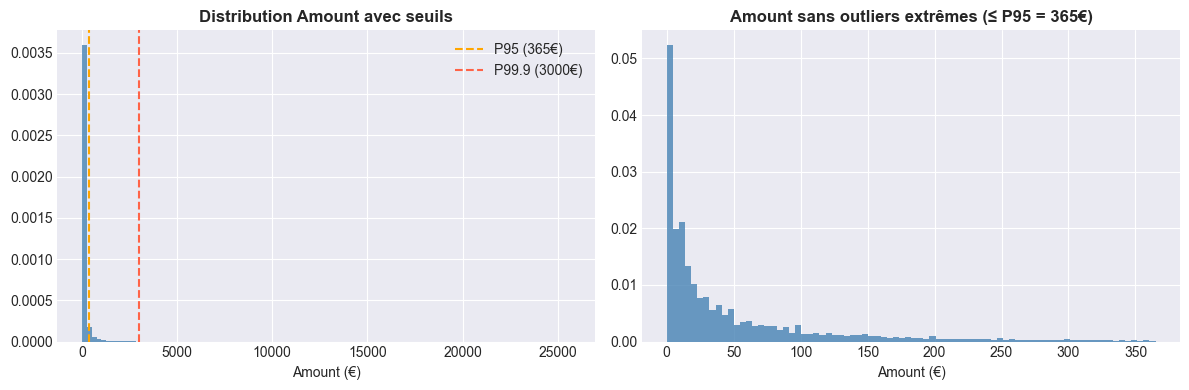

In [12]:
q99 = df[AMOUNT_COL].quantile(0.999)
q95 = df[AMOUNT_COL].quantile(0.95)
outliers_iqr = df[AMOUNT_COL] > q99

print(f'Amount percentiles :')
print(f'  95th : {q95:.2f} €')
print(f'  99.9th : {q99:.2f} €')
print(f'  Max : {df[AMOUNT_COL].max():.2f} €')
print(f'\nOutliers (>99.9th percentile) : {outliers_iqr.sum()} transactions')
print(f'  dont fraudes : {df[outliers_iqr][TARGET_COL].sum()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution Amount avec seuils
axes[0].hist(df[AMOUNT_COL], bins=100, color='steelblue', alpha=0.8, density=True)
axes[0].axvline(q95, color='orange', linestyle='--', label=f'P95 ({q95:.0f}€)')
axes[0].axvline(q99, color='tomato', linestyle='--', label=f'P99.9 ({q99:.0f}€)')
axes[0].set_title('Distribution Amount avec seuils', fontweight='bold')
axes[0].set_xlabel('Amount (€)')
axes[0].legend()

# Zoom sans outliers
axes[1].hist(df[df[AMOUNT_COL] <= q95][AMOUNT_COL], bins=80, color='steelblue', alpha=0.8, density=True)
axes[1].set_title(f'Amount sans outliers extrêmes (≤ P95 = {q95:.0f}€)', fontweight='bold')
axes[1].set_xlabel('Amount (€)')

plt.tight_layout()
plt.savefig('../notebooks/eda_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Conclusions et décisions de modélisation

In [13]:
print('=== SYNTHÈSE EDA ===')
print(f'\n📊 Dataset : {len(df):,} transactions | {df[TARGET_COL].sum()} fraudes ({fraud_rate*100:.3f}%)')
print(f'\n✅ Qualité des données :')
print(f'   • Valeurs manquantes : AUCUNE')
print(f"   • Doublons : {df.duplicated().sum()} ({df.duplicated().mean()*100:.3f}%)")
print(f'\n📈 Métriques retenues :')
print(f'   • Principale : PR-AUC (AUPRC) — robuste au déséquilibre extrême')
print(f'   • Secondaire : ROC-AUC')
print(f'   • Opérationnelle : Recall@Precision≥0.9 (minimiser faux négatifs)')
print(f'   • Rapport : F1-score (fraude)')
print(f'\n🔧 Stratégie de preprocessing :')
print(f'   • StandardScaler sur Amount et Time uniquement (V1-V28 déjà PCA-normalisés)')
print(f'   • Split stratifié 70/10/20 (train/val/test) — seed=42')
print(f'\n⚖️  Gestion du déséquilibre (à comparer dans MLflow) :')
print(f'   1. class_weight="balanced" (référence)')
print(f'   2. SMOTE oversampling')
print(f'   3. scale_pos_weight={int(class_counts[0]/class_counts[1])} pour XGBoost')
print(f'\n🤖 Modèles à entraîner :')
print(f'   1. LogisticRegression (baseline)')
print(f'   2. RandomForestClassifier')
print(f'   3. XGBoostClassifier (candidat champion)')
print(f'\n🎯 Features discriminantes (top 5) : {sep_df.head(5).index.tolist()}')

=== SYNTHÈSE EDA ===

📊 Dataset : 284,807 transactions | 492 fraudes (0.173%)

✅ Qualité des données :
   • Valeurs manquantes : AUCUNE
   • Doublons : 1081 (0.380%)

📈 Métriques retenues :
   • Principale : PR-AUC (AUPRC) — robuste au déséquilibre extrême
   • Secondaire : ROC-AUC
   • Opérationnelle : Recall@Precision≥0.9 (minimiser faux négatifs)
   • Rapport : F1-score (fraude)

🔧 Stratégie de preprocessing :
   • StandardScaler sur Amount et Time uniquement (V1-V28 déjà PCA-normalisés)
   • Split stratifié 70/10/20 (train/val/test) — seed=42

⚖️  Gestion du déséquilibre (à comparer dans MLflow) :
   1. class_weight="balanced" (référence)
   2. SMOTE oversampling
   3. scale_pos_weight=577 pour XGBoost

🤖 Modèles à entraîner :
   1. LogisticRegression (baseline)
   2. RandomForestClassifier
   3. XGBoostClassifier (candidat champion)

🎯 Features discriminantes (top 5) : ['V14', 'V17', 'V12', 'V16', 'V10']
